In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])


In [2]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:

# -------------------------
# Fonctions d'évaluation
# -------------------------

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            y_pred.append(probs.argmax(dim=1).cpu().numpy())
            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_proba),
    )


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


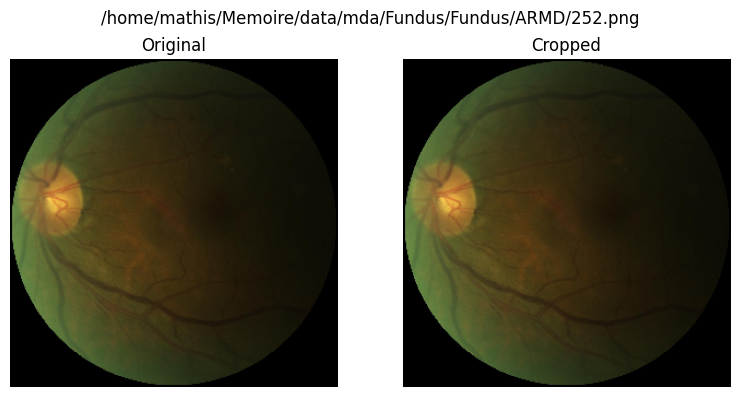

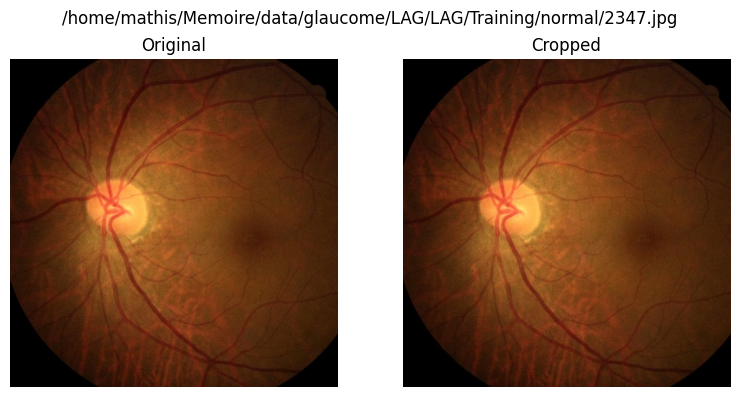

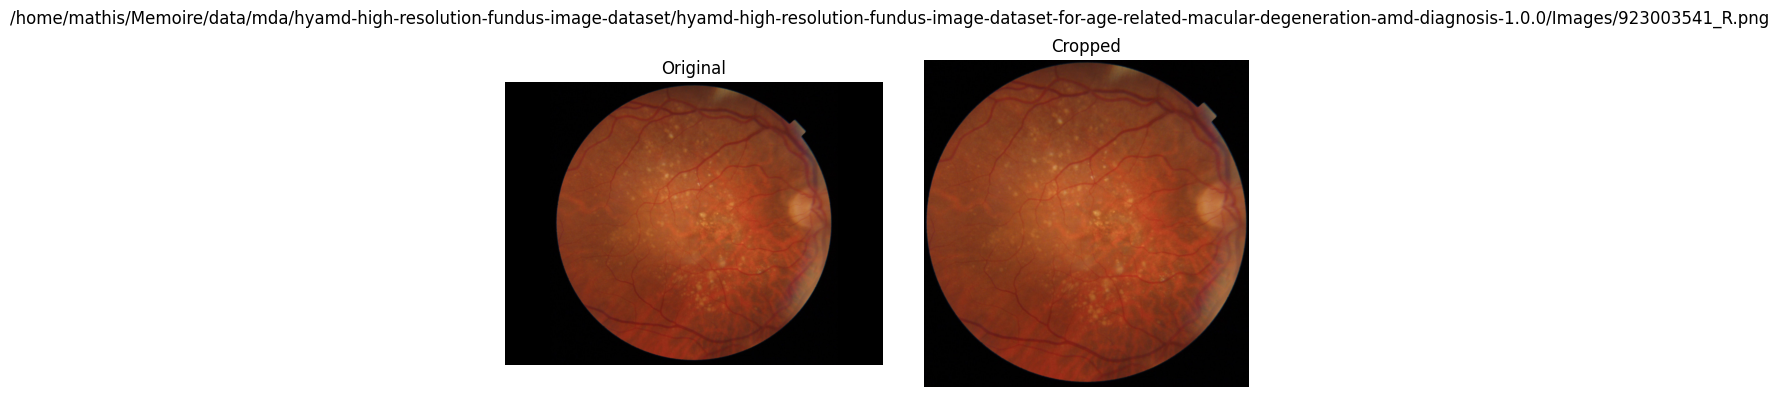

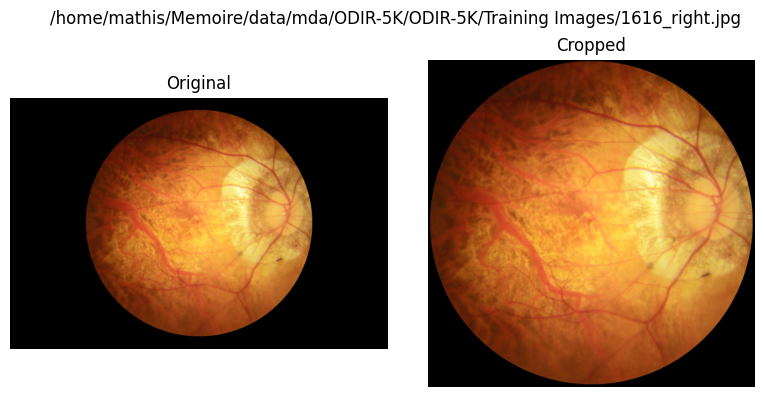

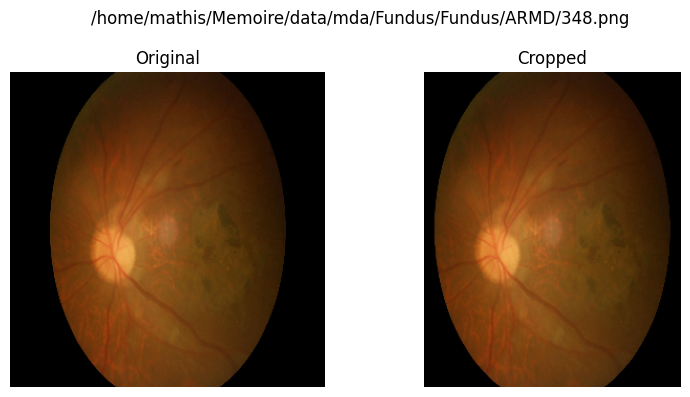

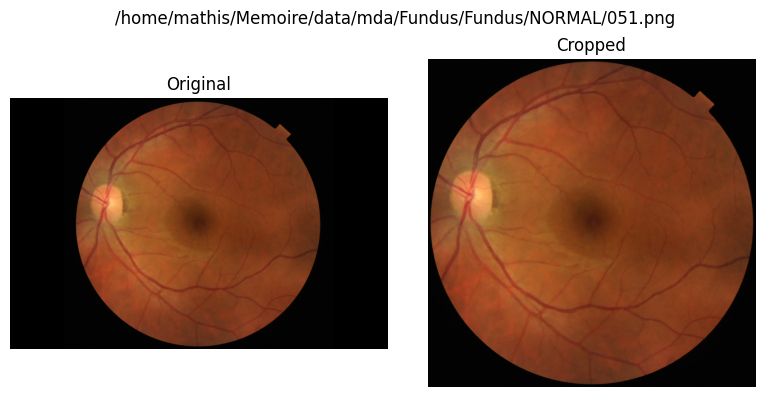

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

sample_paths = df["path"].sample(6, random_state=0).tolist()

for p in sample_paths:
    img = Image.open(p).convert("RGB")
    cropped = crop_black_border_pil(img, thr=10, pad=10)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped")
    axes[1].axis("off")

    fig.suptitle(p)
    plt.tight_layout()
    plt.show()


In [5]:

# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# Amélioration 2 : augmentation plus forte
# Amélioration 3 : résolution 256→crop 224
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

val_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y


train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle ResNet50 — Amélioration 1
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Amélioration 1 : fine-tuning progressif
# backbone (layer1-4) : lr faible  |  tête fc : lr plus élevé
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621
Epoch 01 | train loss 1.2012 acc 0.5381 | val loss 0.9035 acc 0.6828
Epoch 02 | train loss 0.8025 acc 0.6818 | val loss 0.6710 acc 0.7182
Epoch 03 | train loss 0.6681 acc 0.7205 | val loss 0.5966 acc 0.7424
Epoch 04 | train loss 0.6097 acc 0.7433 | val loss 0.5495 acc 0.7552
Epoch 05 | train loss 0.5706 acc 0.7580 | val loss 0.5198 acc 0.7729
Epoch 06 | train loss 0.5456 acc 0.7682 | val loss 0.4858 acc 0.7939
Epoch 07 | train loss 0.5105 acc 0.7807 | val loss 0.4707 acc 0.7939
Epoch 08 | train loss 0.4934 acc 0.7934 | val loss 0.4654 acc 0.7826
Epoch 09 | train loss 0.4780 acc 0.7910 | val loss 0.4563 acc 0.7939
Epoch 10 | train loss 0.4564 acc 0.8047 | val loss 0.4427 acc 0.7874



=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            120              2         6            27
True_glaucome             0            149         0             6
True_mda                  1              0       146             9
True_normaux             37             27        12            79


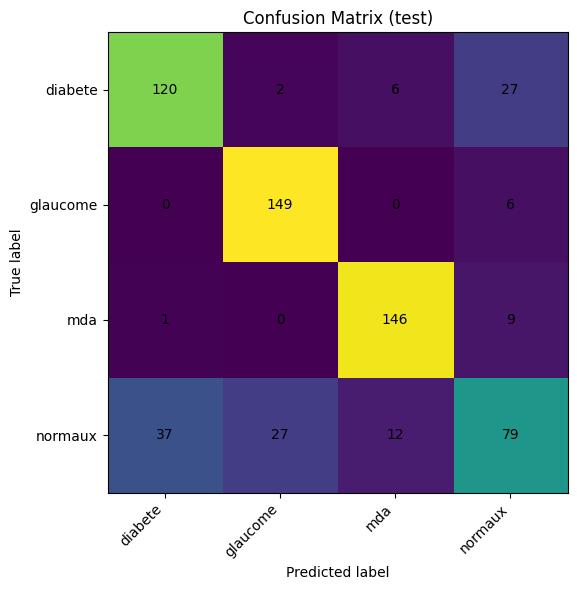


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7595    0.7742    0.7668       155
    glaucome     0.8371    0.9613    0.8949       155
         mda     0.8902    0.9359    0.9125       156
     normaux     0.6529    0.5097    0.5725       155

    accuracy                         0.7955       621
   macro avg     0.7849    0.7953    0.7867       621
weighted avg     0.7851    0.7955    0.7869       621



In [6]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 127


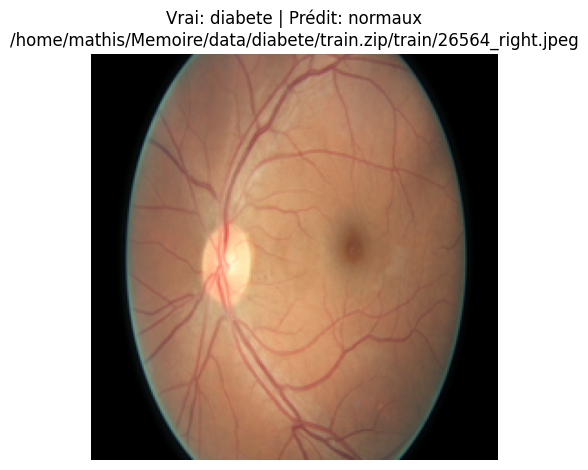

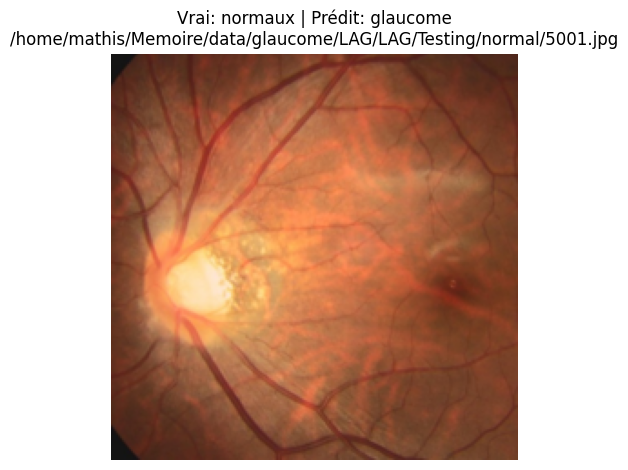

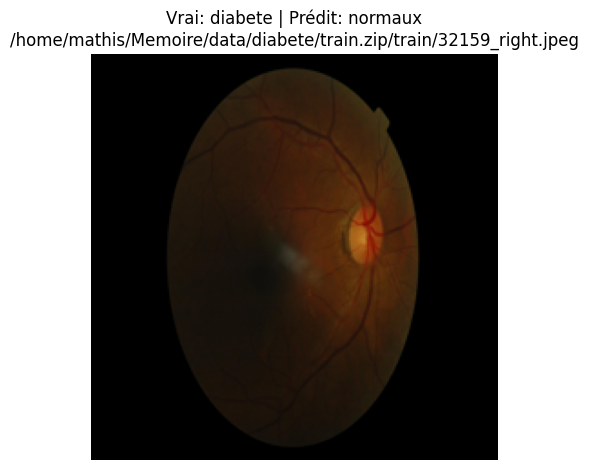

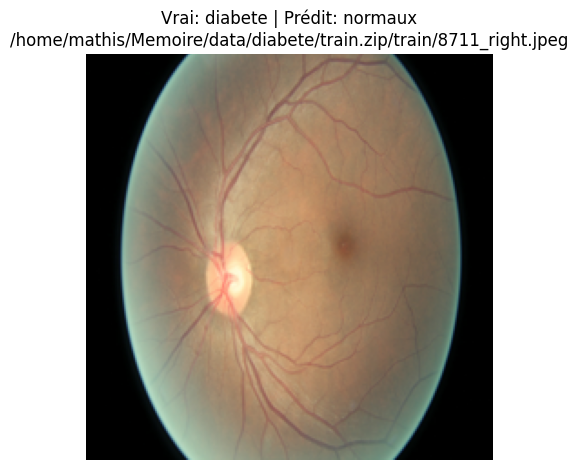

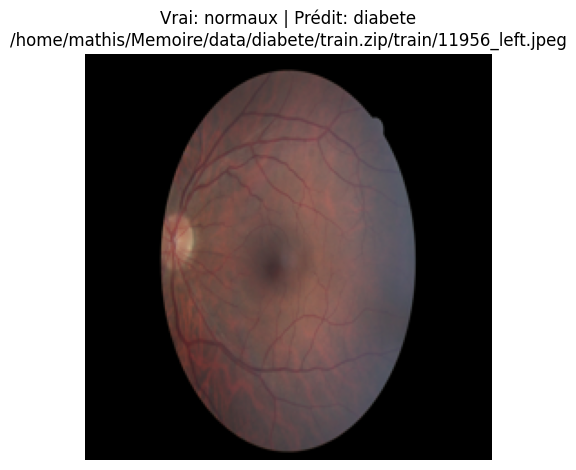

In [7]:

# Exemples d'images mal classées (PyTorch/PIL uniquement)
df_test = test_df.reset_index(drop=True)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]["path"]
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]

    img = Image.open(img_path).convert("RGB").resize((224, 224))

    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}\n{img_path}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [8]:

# Amélioration 1 : fine-tuning progressif (cohérent avec cell 7)
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break


Epoch 01 | train loss 0.4572 train acc 0.8073 | val loss 0.4374 val acc 0.7874 | lr 1.00e-05 
Epoch 02 | train loss 0.4412 train acc 0.8083 | val loss 0.4318 val acc 0.8068 | lr 1.00e-05 
Epoch 03 | train loss 0.4341 train acc 0.8141 | val loss 0.4263 val acc 0.8019 | lr 1.00e-05 
Epoch 04 | train loss 0.4119 train acc 0.8216 | val loss 0.4140 val acc 0.8052 | lr 1.00e-05 
Epoch 05 | train loss 0.4046 train acc 0.8272 | val loss 0.4090 val acc 0.8148 | lr 1.00e-05 
Epoch 06 | train loss 0.4016 train acc 0.8280 | val loss 0.4168 val acc 0.8084 | lr 1.00e-05 
Epoch 07 | train loss 0.3823 train acc 0.8411 | val loss 0.3839 val acc 0.8293 | lr 1.00e-05 
Epoch 08 | train loss 0.3743 train acc 0.8427 | val loss 0.3954 val acc 0.8052 | lr 1.00e-05 
Epoch 09 | train loss 0.3685 train acc 0.8411 | val loss 0.3927 val acc 0.8148 | lr 1.00e-05 
Epoch 10 | train loss 0.3529 train acc 0.8443 | val loss 0.3872 val acc 0.8213 | lr 1.00e-05 
Epoch 11 | train loss 0.3485 train acc 0.8524 | val loss 0.3


=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            112              0         3            40
True_glaucome             1            150         0             4
True_mda                  2              0       144            10
True_normaux             26             15         8           106


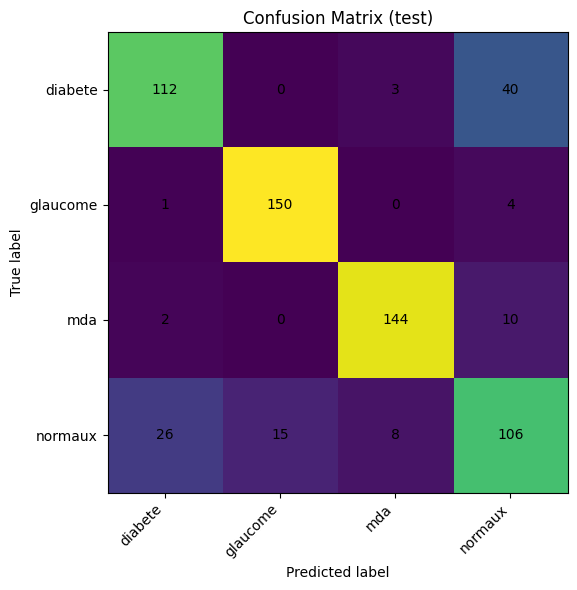


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7943    0.7226    0.7568       155
    glaucome     0.9091    0.9677    0.9375       155
         mda     0.9290    0.9231    0.9260       156
     normaux     0.6625    0.6839    0.6730       155

    accuracy                         0.8245       621
   macro avg     0.8237    0.8243    0.8233       621
weighted avg     0.8239    0.8245    0.8235       621



In [9]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 109


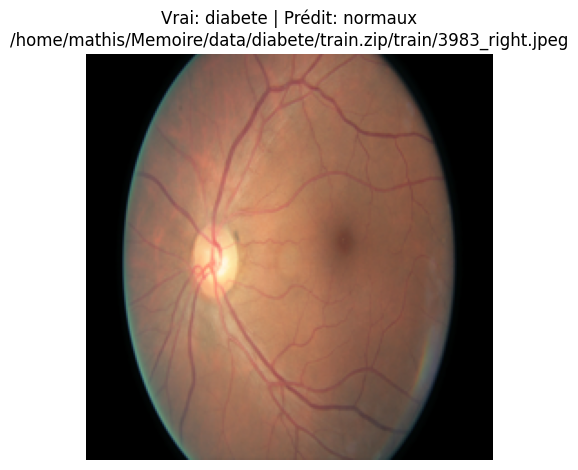

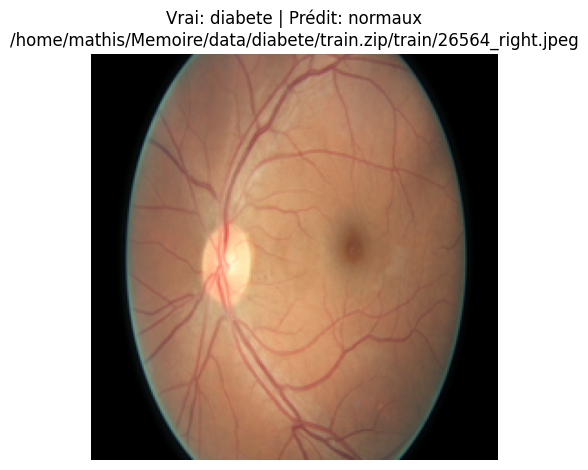

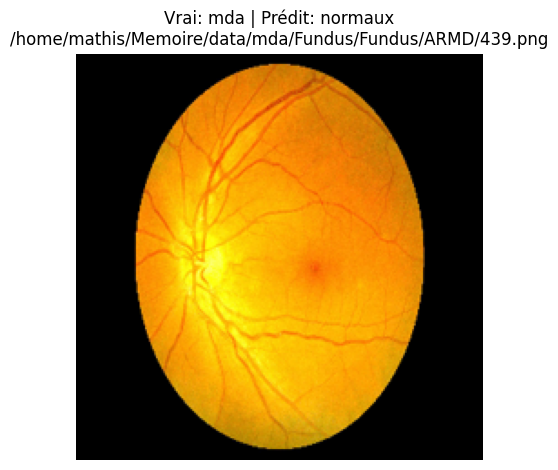

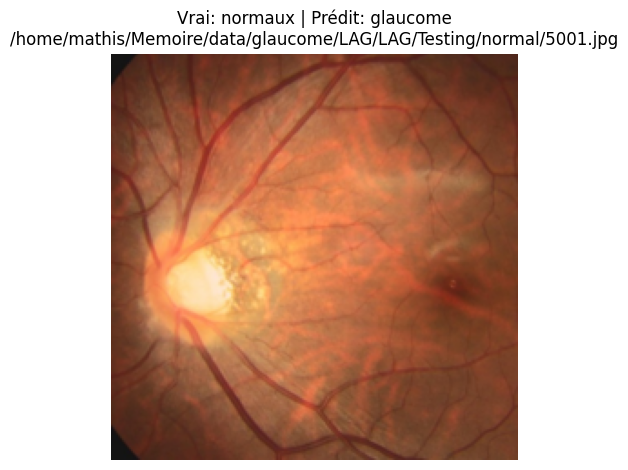

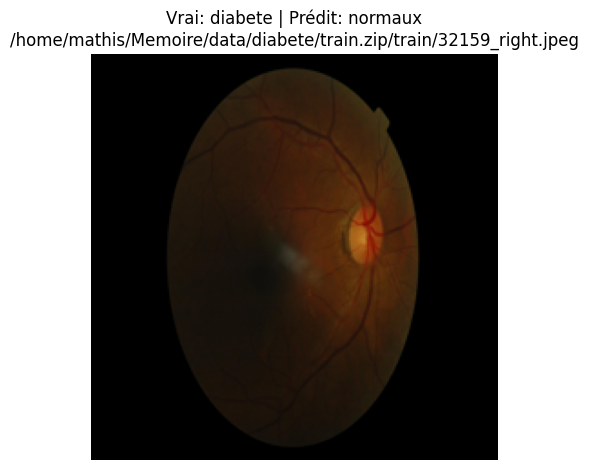

In [10]:

# Exemples d'images mal classées (PyTorch/PIL uniquement)
df_test = test_df.reset_index(drop=True)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]["path"]
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]

    img = Image.open(img_path).convert("RGB").resize((224, 224))

    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}\n{img_path}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
